In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import kagglehub

path = kagglehub.dataset_download("lepchenkov/usedcarscatalog")
df = pd.read_csv(f"{path}/cars.csv")

features = ['year_produced', 'odometer_value', 'engine_capacity']
df['engine_capacity'] = df['engine_capacity'].fillna(df['engine_capacity'].median())

X = df[features].to_numpy()
Y = df['price_usd'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"X_train shape: {X_train.shape}")

X_train shape: (30824, 3)


In [43]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mmse_solve(X, y):
    X_b = np.c_[X, np.ones(X.shape[0])]
    w_hat = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return w_hat[:-1], w_hat[-1]

w_mmse, b_mmse = mmse_solve(X_train, y_train)
mse_mmse = mse(y_test, X_test.dot(w_mmse) + b_mmse)
print(f"МНК: MSE={mse_mmse:.2f}")

МНК: MSE=16219710.47


In [44]:
def gradient_descent(X, y, lr=0.1, epochs=5000):
    Xm, Xs = X.mean(axis=0), X.std(axis=0)
    ym, ys = y.mean(), y.std()
    Xn = (X - Xm) / Xs
    yn = (y - ym) / ys
    
    w = np.zeros(X.shape[1])
    b = 0.0
    n = len(Xn)
    
    for _ in range(epochs):
        yp = Xn.dot(w) + b
        err = yp - yn
        w -= lr * (2/n) * Xn.T.dot(err)
        b -= lr * (2/n) * np.sum(err)
        
    w = w * ys / Xs
    b = (b * ys + ym) - np.sum(w * Xm)
    return w, b

w_gd, b_gd = gradient_descent(X_train, y_train)
mse_gd = mse(y_test, X_test.dot(w_gd) + b_gd)
print(f"GD: MSE={mse_gd:.2f}")

GD: MSE=16219710.47


In [45]:
yp = X_train.dot(w_mmse) + b_mmse
ym = y_train.mean()

SSE = np.sum((y_train - yp) ** 2)
SST = np.sum((y_train - ym) ** 2)

n = len(X_train)
k = X_train.shape[1]
R2 = 1 - SSE / SST

# Валидация Стьюдентом
mse_val = SSE / (n - k - 1)
t_crit = stats.t.ppf(0.975, n - k - 1)  # Двусторонний 95%
margin_of_error = t_crit * np.sqrt(mse_val)


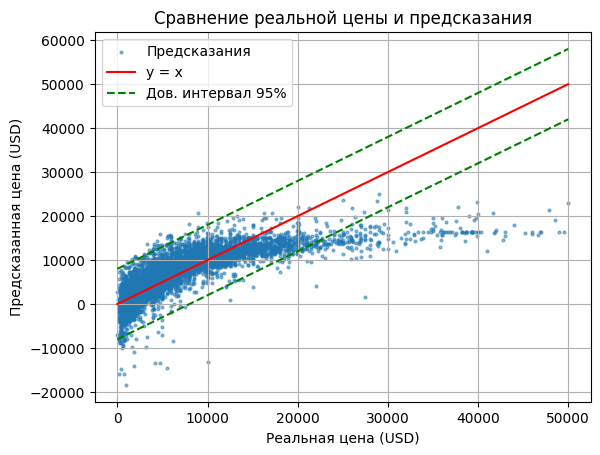

w: [4065.98558222 -956.17773217 1966.85214066]
b: 6648.45


In [46]:
yp_mmse = X_test.dot(w_mmse) + b_mmse

plt.figure()
plt.scatter(y_test, yp_mmse, alpha=0.5, label='Предсказания', s=4)

# Линия совпадения (y = x)
max_val = max(y_test.max(), yp_mmse.max())
trend_line = np.array([0, max_val])
plt.plot(trend_line, trend_line, color='red', label='y = x')

# Доверительный интервал (Стьюдент)
plt.plot(trend_line, trend_line + margin_of_error, color='green', linestyle='--', label='Дов. интервал 95%')
plt.plot(trend_line, trend_line - margin_of_error, color='green', linestyle='--')

plt.title("Сравнение реальной цены и предсказания")
plt.xlabel("Реальная цена (USD)")
plt.ylabel("Предсказанная цена (USD)")

plt.legend()
plt.grid()
plt.show()

print(f"w: {w_mmse}")
print(f"b: {b_mmse:.2f}")


In [47]:

SSR = np.sum((yp - ym) ** 2)
SSE = np.sum((y_train - yp) ** 2)
F = (SSR / k) / (SSE / (n - k - 1))
S2 = SSE / (n - k - 1)

X_b = np.c_[X_train, np.ones(n)]
mj = np.sqrt(np.diagonal(S2 * np.linalg.inv(X_b.T.dot(X_b))))
t = np.append(w_mmse, b_mmse) / mj

F_crit = stats.f.ppf(0.95, k, n - k - 1)
t_crit = stats.t.ppf(0.975, n - k - 1)

print(f"SSR = {SSR:.2f}")
print(f"SSE = {SSE:.2f}")
print(f"S2 = {S2:.2f}")
print(f"mj = {np.round(mj, 2)}")
print(f"F_crit = {F_crit:.2f}")
print(f"t_crit = {t_crit:.2f}")
print(f"F = {F:.2f}")
print(f"t = {np.round(t, 2)}")

SSR = 763607174094.51
SSE = 513310405553.31
S2 = 16655107.25
mj = [26.59 26.75 23.44 23.24]
F_crit = 2.61
t_crit = 1.96
F = 15282.74
t = [152.91 -35.75  83.93 286.02]
